# Module 1 — Weighted Feature Availability Score

This notebook rewrites **Module 1: Structured Field Completeness** into a stronger version.

Instead of asking only:

> Is this XML/CSV column filled?

we ask:

> Can this STR provide the raw structured information needed to compute important AML features?

This is better for the hackathon because all columns do not have equal analytical value. A missing reporter title is not as serious as a missing transaction amount, transaction date, sender account, receiver account, or account-opened date.

## Main idea

We map important AML features, such as `sender_account_age_days`, `log_amount`, `is_weekend`, `cross_border_flag`, and `transmode_A`, back to the raw STR fields needed to compute them.

Then Module 1 becomes a **weighted feature availability score**.

## 1. Load the STR CSV

In [1]:

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('xml_output.csv')  # change this path if running locally

df = pd.read_csv(DATA_PATH)
print(f"Rows / reports: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head(3)


Rows / reports: 276
Columns: 501


,report_rentity_id,report_rentity_branch,report_submission_code,report_report_code,report_entity_reference,report_report_id,report_submission_date,report_currency_code_local,report_reporting_person_gender,report_reporting_person_title,report_reporting_person_first_name,report_reporting_person_last_name,report_reporting_person_birthdate,report_reporting_person_ssn,report_reporting_person_phones_phone_tph_contact_type,report_reporting_person_phones_phone_tph_communication_type,report_reporting_person_phones_phone_tph_country_prefix,report_reporting_person_phones_phone_tph_number,report_reporting_person_occupation,report_location_address_type,report_location_address,report_location_town,report_location_city,report_location_zip,report_location_country_code,report_location_state,report_reason,report_transaction_transactionnumber,report_transaction_internal_ref_number,report_transaction_transaction_location,report_transaction_date_transaction,report_transaction_value_date,report_transaction_transmode_code,report_transaction_transmode_comment,report_transaction_amount_local,report_transaction_t_from_my_client_from_funds_code,report_transaction_t_from_my_client_from_foreign_currency_foreign_currency_code,report_transaction_t_from_my_client_from_foreign_currency_foreign_amount,report_transaction_t_from_my_client_from_foreign_currency_foreign_exchange_rate,report_transaction_t_from_my_client_from_account_institution_name,report_transaction_t_from_my_client_from_account_institution_code,report_transaction_t_from_my_client_from_account_branch,report_transaction_t_from_my_client_from_account_account,report_transaction_t_from_my_client_from_account_currency_code,report_transaction_t_from_my_client_from_account_account_name,report_transaction_t_from_my_client_from_account_personal_account_type,report_transaction_t_from_my_client_from_account_signatory_is_primary,report_transaction_t_from_my_client_from_account_signatory_t_person_gender,report_transaction_t_from_my_client_from_account_signatory_t_person_title,report_transaction_t_from_my_client_from_account_signatory_t_person_first_name,report_transaction_t_from_my_client_from_account_signatory_t_person_last_name,report_transaction_t_from_my_client_from_account_signatory_t_person_birthdate,report_transaction_t_from_my_client_from_account_signatory_t_person_birth_place,report_transaction_t_from_my_client_from_account_signatory_t_person_mothers_name,report_transaction_t_from_my_client_from_account_signatory_t_person_ssn,report_transaction_t_from_my_client_from_account_signatory_t_person_passport_number,report_transaction_t_from_my_client_from_account_signatory_t_person_passport_country,report_transaction_t_from_my_client_from_account_signatory_t_person_nationality1,report_transaction_t_from_my_client_from_account_signatory_t_person_residence,report_transaction_t_from_my_client_from_account_signatory_t_person_phones_phone_tph_contact_type,...,report_transaction_6_transaction_transmode_comment,report_transaction_6_transaction_amount_local,report_transaction_6_transaction_t_from_my_client_from_funds_code,report_transaction_6_transaction_t_from_my_client_from_foreign_currency_foreign_currency_code,report_transaction_6_transaction_t_from_my_client_from_foreign_currency_foreign_amount,report_transaction_6_transaction_t_from_my_client_from_foreign_currency_foreign_exchange_rate,report_transaction_6_transaction_t_from_my_client_from_account_institution_name,report_transaction_6_transaction_t_from_my_client_from_account_institution_code,report_transaction_6_transaction_t_from_my_client_from_account_branch,report_transaction_6_transaction_t_from_my_client_from_account_account,report_transaction_6_transaction_t_from_my_client_from_account_currency_code,report_transaction_6_transaction_t_from_my_client_from_account_account_name,report_transaction_6_transaction_t_from_my_client_from_account_personal_account_type,report_transaction_6_transaction_t_from_my_client_from_account_signatory_is_primary,report_trans

##  weighted feature availability

1. Start from important AML/suspiciousness features.
2. Identify the raw STR fields required to compute each feature.
3. Give higher Module 1 weight to fields that support more important analysis.
4. Put unavailable but useful features into a **should be included list**.

In [2]:

feature_mapping = pd.DataFrame([
    ['sender_account_age_days', 'sender account opened date + transaction date', 'available / derivable', 'Compute transaction_date - sender_account_opened_date.'],
    ['receiver_account_age_days', 'receiver account opened date + transaction date', 'available / derivable', 'Compute transaction_date - receiver_account_opened_date.'],
    ['amount_local_npr, log_amount, amount_zscore, above_1M_NPR, above_10M_NPR', 'transaction amount local', 'available / derivable', 'All amount-risk features come from transaction amount.'],
    ['day_of_week, is_weekend, hour_of_day', 'transaction date/time', 'available / derivable', 'Date/time features are derived from transaction datetime.'],
    ['cross_border_flag', 'from country + to country', 'available / derivable', 'Can compare sender and receiver countries.'],
    ['currency_mismatch', 'local currency + sender account currency + receiver account currency + foreign currency fields', 'available / partly derivable', 'Currency columns exist, but mismatch logic depends on business rule.'],
    ['transmode_A, transmode_E, transmode_F, transmode_J, transmode_P', 'transaction mode code', 'available / derivable', 'One-hot encode transaction mode code.'],
    ['tx_count_10, tx_count_30, velocity_sum_10tx', 'historical transaction data', 'partly available only inside each STR', 'True velocity requires full transaction history, not only transactions embedded in one STR.'],
    ['sender_country_risk, receiver_country_risk', 'country + external country risk score table', 'country available, risk table missing', 'Should be enriched using an external risk lookup table.'],
    ['sender_pep, receiver_pep, sanctions flags, adverse media', 'PEP/sanctions/adverse media screening fields', 'not clearly available', 'Should be included as structured risk flags.'],
], columns=['suggested_feature', 'raw_fields_needed', 'status_in_this_csv', 'notes'])

feature_mapping


,suggested_feature,raw_fields_needed,status_in_this_csv,notes
0,sender_account_age_days,sender account opened date + transaction date,available / derivable,Compute transaction_date - sender_account_opened_date.
1,receiver_account_age_days,receiver account opened date + transaction date,available / derivable,Compute transaction_date - receiver_account_opened_date.
2,"amount_local_npr, log_amount, amount_zscore, above_1M_NPR, above_10M_NPR",transaction amount local,available / derivable,All amount-risk features come from transaction amount.
3,"day_of_week, is_weekend, hour_of_day",transaction date/time,available / derivable,Date/time features are derived from transaction datetime.
4,cross_border_flag,from country + to country,available / derivable,Can compare sender and receiver countries.
5,currency_mismatch,local currency + sender account currency + receiver account currency + foreign currency fields,available / partly derivable,"Currency columns exist, but mismatch logic depends on business rule."
6,"transmode_A, transmode_E, transmode_F, transmode_J, transmode_P",transaction mode code,available / derivable,One-hot encode transaction mode code.
7,"tx_count_10, tx_count_30, velocity_sum_10tx",historical transaction data,partly available only inside each STR,"True velocity requires full transaction history, not only transactions embedded in one STR."
8,"sender_country_risk, receiver_country_risk",country + external country risk score table,"country available, risk table missing",Should be enriched using an external risk lookup table.
9,"sender_pep, receiver_pep, sanctions flags, adverse media",PEP/sanctions/adverse media screening fields,not clearly available,Should be included as structured risk flags.


## 3. Should be included list

These are useful AML features or raw data fields that are missing or only partially supported in the current STR CSV. We should not pretend they exist. Instead, the notebook explicitly lists them as fields that should be added in a better STR data model.

In [3]:

should_be_included = pd.DataFrame([
    ['Full transaction history for last 10 transactions', 'Needed for true tx_count_10 and velocity_sum_10tx.'],
    ['Full transaction history for last 30 days', 'Needed for tx_count_30 and recent activity pattern analysis.'],
    ['Historical velocity amount windows', 'Needed to compare the STR transaction against previous activity.'],
    ['Sender country risk score', 'Sender country exists, but there is no structured risk score.'],
    ['Receiver country risk score', 'Receiver country exists, but there is no structured risk score.'],
    ['Sender PEP flag', 'No clear structured PEP flag found.'],
    ['Receiver PEP flag', 'No clear structured PEP flag found.'],
    ['Sender sanctions screening result', 'No clear structured sanctions field found.'],
    ['Receiver sanctions screening result', 'No clear structured sanctions field found.'],
    ['Adverse media screening flag', 'No clear structured adverse media field found.'],
    ['Customer expected income / KYC profile', 'Needed to judge whether activity is inconsistent with profile.'],
    ['Expected monthly transaction behavior', 'Needed to compare actual transaction behavior against normal behavior.'],
    ['Customer explanation / response', 'Very important for report usefulness; should be narrative or structured.'],
    ['Relationship start date with institution', 'Account opened date exists, but full customer relationship age would be stronger.'],
    ['Beneficial ownership details', 'Important for entity/company accounts.'],
    ['Business sector risk category', 'Entity business may exist, but no standardized risk category is present.'],
    ['Alert trigger / rule ID', 'Useful to know why the transaction was flagged.'],
    ['Previous STR/SAR history', 'Important for repeat suspicious behavior.'],
    ['Investigation outcome / analyst note', 'Useful for validation and improving the scoring system later.'],
], columns=['should_be_included_field', 'why_it_matters'])

should_be_included


,should_be_included_field,why_it_matters
0,Full transaction history for last 10 transactions,Needed for true tx_count_10 and velocity_sum_10tx.
1,Full transaction history for last 30 days,Needed for tx_count_30 and recent activity pattern analysis.
2,Historical velocity amount windows,Needed to compare the STR transaction against previous activity.
3,Sender country risk score,"Sender country exists, but there is no structured risk score."
4,Receiver country risk score,"Receiver country exists, but there is no structured risk score."
5,Sender PEP flag,No clear structured PEP flag found.
6,Receiver PEP flag,No clear structured PEP flag found.
7,Sender sanctions screening result,No clear structured sanctions field found.
8,Receiver sanctions screening result,No clear structured sanctions field found.
9,Adverse media screening flag,No clear structured adverse media field found.


## 4. Discover transaction blocks

The CSV has one main transaction block and repeated transaction blocks like `report_transaction_2_transaction_...`, `report_transaction_3_transaction_...`, and so on. The scoring function should score every active transaction block inside each STR.

In [4]:

all_columns = df.columns.tolist()
transaction_prefixes = ['report_transaction']

for col in all_columns:
    match = re.match(r'^(report_transaction_\d+_transaction)_', col)
    if match:
        transaction_prefixes.append(match.group(1))

transaction_prefixes = sorted(
    set(transaction_prefixes),
    key=lambda x: (0 if x == 'report_transaction' else int(re.search(r'_(\d+)_', x).group(1)))
)

print('Transaction blocks found:')
for p in transaction_prefixes:
    print('-', p)


Transaction blocks found:
- report_transaction
- report_transaction_2_transaction
- report_transaction_3_transaction
- report_transaction_4_transaction
- report_transaction_5_transaction
- report_transaction_6_transaction


## 5. Weighted Module 1 design

The score is still from 0 to 1, but now each group has a different weight based on analytical usefulness.

| Feature group | Weight | Why it matters |
|---|---:|---|
| Account age computability | 25% | Account age was a high-importance feature; it needs account-opened date and transaction date. |
| Amount risk computability | 20% | Amount supports log amount, z-score, threshold flags, and high-value prioritization. |
| Sender/receiver identity completeness | 20% | Analysts must know who sent and received the money. |
| Transaction date/time computability | 15% | Supports day, weekend, hour, value date, and temporal analysis. |
| Corridor/currency computability | 10% | Supports cross-border flag and currency mismatch. |
| Transaction mode/funds specificity | 10% | Supports transaction-mode one-hot features and method-of-movement analysis. |

Total = 100% of Module 1.

In [5]:

GROUP_WEIGHTS = {
    'account_age_computability': 0.25,
    'amount_risk_computability': 0.20,
    'identity_completeness': 0.20,
    'transaction_time_computability': 0.15,
    'corridor_currency_computability': 0.10,
    'mode_funds_specificity': 0.10,
}

pd.DataFrame(
    [{'feature_group': k, 'module1_weight': v} for k, v in GROUP_WEIGHTS.items()]
).sort_values('module1_weight', ascending=False)


,feature_group,module1_weight
0,account_age_computability,0.25
1,amount_risk_computability,0.20
2,identity_completeness,0.20
3,transaction_time_computability,0.15
4,corridor_currency_computability,0.10
5,mode_funds_specificity,0.10


## 6. Helper functions

These helpers check whether values are present, specific, parseable, and useful. A field can be filled but still weak if it is generic, such as `UNKNOWN`, `N/A`, `OTHER`, or a placeholder account number like `000000`.

In [6]:

GENERIC_VALUES = {
    '', 'nan', 'none', 'null', 'na', 'n/a', 'not available', 'unknown', 'unk',
    'other', 'misc', 'not applicable', 'nil', 'missing'
}
GENERIC_CODE_VALUES = GENERIC_VALUES | {'z', 'zz', 'zzz', '999', '9999', '00', '000', 'oth'}

def raw_value(row, col):
    if col not in row.index:
        return np.nan
    return row[col]

def is_missing_like(value):
    if pd.isna(value):
        return True
    s = str(value).strip()
    if not s:
        return True
    return s.lower() in GENERIC_VALUES

def is_placeholder_number(value):
    if pd.isna(value):
        return True
    s = re.sub(r'\D', '', str(value))
    if not s:
        return False
    return len(s) >= 4 and len(set(s)) == 1

def valid_text(row, col, coded=False, allow_short_code=True):
    value = raw_value(row, col)
    if is_missing_like(value):
        return 0.0
    s = str(value).strip().lower()
    if coded and s in GENERIC_CODE_VALUES:
        return 0.0
    if not allow_short_code and len(s) <= 1:
        return 0.0
    return 1.0

def valid_account(row, col):
    value = raw_value(row, col)
    if is_missing_like(value):
        return 0.0
    if is_placeholder_number(value):
        return 0.0
    return 1.0

def valid_amount(row, col):
    value = raw_value(row, col)
    if is_missing_like(value):
        return 0.0
    s = str(value).replace(',', '').strip()
    try:
        return 1.0 if float(s) > 0 else 0.0
    except ValueError:
        return 0.0

def valid_date(row, col):
    value = raw_value(row, col)
    if is_missing_like(value):
        return 0.0
    parsed = pd.to_datetime(value, errors='coerce')
    return 0.0 if pd.isna(parsed) else 1.0

def pair_derivable(score_a, score_b):
    # A derived feature is strongest when both raw fields exist.
    # If one side exists, give partial credit.
    if score_a == 1.0 and score_b == 1.0:
        return 1.0
    if score_a == 1.0 or score_b == 1.0:
        return 0.5
    return 0.0

def weighted_average(parts):
    total_weight = sum(w for _, w in parts)
    if total_weight == 0:
        return 0.0
    return sum(score * weight for score, weight in parts) / total_weight


## 7. Scoring one transaction block

Each transaction block is scored using the same logic. Then the report-level score is the average across active transaction blocks.

In [7]:

def has_active_transaction_block(row, prefix):
    key_suffixes = [
        'transactionnumber', 'date_transaction', 'amount_local',
        't_from_my_client_from_account_account',
        't_to_to_account_account'
    ]
    for suffix in key_suffixes:
        col = f'{prefix}_{suffix}'
        if col in row.index and not is_missing_like(row[col]):
            return True
    return False

def score_transaction_block(row, prefix):
    tx_date = f'{prefix}_date_transaction'
    value_date = f'{prefix}_value_date'
    amount = f'{prefix}_amount_local'
    transmode_code = f'{prefix}_transmode_code'
    transmode_comment = f'{prefix}_transmode_comment'
    from_funds = f'{prefix}_t_from_my_client_from_funds_code'
    to_funds = f'{prefix}_t_to_to_funds_code'

    sender_opened = f'{prefix}_t_from_my_client_from_account_opened'
    receiver_opened = f'{prefix}_t_to_to_account_opened'
    sender_account = f'{prefix}_t_from_my_client_from_account_account'
    sender_account_name = f'{prefix}_t_from_my_client_from_account_account_name'
    sender_person_first = f'{prefix}_t_from_my_client_from_account_signatory_t_person_first_name'
    sender_person_last = f'{prefix}_t_from_my_client_from_account_signatory_t_person_last_name'
    sender_entity_name = f'{prefix}_t_from_my_client_from_account_t_entity_name'
    receiver_account = f'{prefix}_t_to_to_account_account'
    receiver_account_name = f'{prefix}_t_to_to_account_account_name'
    sender_institution = f'{prefix}_t_from_my_client_from_account_institution_name'
    receiver_institution = f'{prefix}_t_to_to_account_institution_name'
    sender_branch = f'{prefix}_t_from_my_client_from_account_branch'
    receiver_branch = f'{prefix}_t_to_to_account_branch'
    from_country = f'{prefix}_t_from_my_client_from_country'
    to_country = f'{prefix}_t_to_to_country'
    sender_currency = f'{prefix}_t_from_my_client_from_account_currency_code'
    receiver_currency = f'{prefix}_t_to_to_account_currency_code'

    tx_date_score = valid_date(row, tx_date)
    sender_age_score = pair_derivable(valid_date(row, sender_opened), tx_date_score)
    receiver_age_score = pair_derivable(valid_date(row, receiver_opened), tx_date_score)
    account_age_score = weighted_average([(sender_age_score, 0.50), (receiver_age_score, 0.50)])

    amount_score = weighted_average([
        (valid_amount(row, amount), 0.80),
        (valid_text(row, 'report_currency_code_local', coded=True), 0.20),
    ])

    sender_person_or_entity = max(
        weighted_average([(valid_text(row, sender_person_first), 0.50), (valid_text(row, sender_person_last), 0.50)]),
        valid_text(row, sender_entity_name)
    )
    institution_score = weighted_average([
        (valid_text(row, sender_institution), 0.30),
        (valid_text(row, receiver_institution), 0.30),
        (valid_text(row, sender_branch), 0.20),
        (valid_text(row, receiver_branch), 0.20),
    ])
    identity_score = weighted_average([
        (valid_account(row, sender_account), 0.25),
        (valid_text(row, sender_account_name), 0.15),
        (sender_person_or_entity, 0.15),
        (valid_account(row, receiver_account), 0.25),
        (valid_text(row, receiver_account_name), 0.15),
        (institution_score, 0.05),
    ])

    time_score = weighted_average([
        (tx_date_score, 0.80),
        (valid_date(row, value_date), 0.10),
        (valid_date(row, 'report_submission_date'), 0.10),
    ])

    corridor_currency_score = weighted_average([
        (valid_text(row, from_country, coded=True), 0.35),
        (valid_text(row, to_country, coded=True), 0.35),
        (valid_text(row, sender_currency, coded=True), 0.15),
        (valid_text(row, receiver_currency, coded=True), 0.15),
    ])

    mode_funds_score = weighted_average([
        (valid_text(row, transmode_code, coded=True), 0.40),
        (valid_text(row, transmode_comment), 0.20),
        (valid_text(row, from_funds, coded=True), 0.20),
        (valid_text(row, to_funds, coded=True), 0.20),
    ])

    group_scores = {
        'account_age_computability': account_age_score,
        'amount_risk_computability': amount_score,
        'identity_completeness': identity_score,
        'transaction_time_computability': time_score,
        'corridor_currency_computability': corridor_currency_score,
        'mode_funds_specificity': mode_funds_score,
    }
    weighted_score = sum(group_scores[group] * GROUP_WEIGHTS[group] for group in GROUP_WEIGHTS)

    gaps = []
    if sender_age_score < 1.0:
        gaps.append('sender account age not fully computable: need sender account opened date + transaction date')
    if receiver_age_score < 1.0:
        gaps.append('receiver account age not fully computable: need receiver account opened date + transaction date')
    if valid_amount(row, amount) < 1.0:
        gaps.append('transaction amount missing or invalid')
    if tx_date_score < 1.0:
        gaps.append('transaction date/time missing or invalid')
    if identity_score < 0.80:
        gaps.append('sender/receiver identity fields incomplete')
    if corridor_currency_score < 0.80:
        gaps.append('country/currency fields incomplete for cross-border or mismatch analysis')
    if mode_funds_score < 0.80:
        gaps.append('transaction mode or funds-code fields are missing/generic')

    return {'block_prefix': prefix, 'block_score': weighted_score, **group_scores, 'block_gaps': gaps}


## 8. Score each STR report

For each report, we detect active transaction blocks, score each active block, average group scores, generate a final weighted Module 1 score, and output gap messages.

In [8]:

def score_report_module1(row):
    active_blocks = [p for p in transaction_prefixes if has_active_transaction_block(row, p)]
    if not active_blocks:
        return {
            'report_id': raw_value(row, 'report_report_id'),
            'module1_weighted_score': 0.0,
            'active_transaction_blocks': 0,
            **{group: 0.0 for group in GROUP_WEIGHTS},
            'gaps': ['no active transaction block found'],
        }

    block_results = [score_transaction_block(row, p) for p in active_blocks]
    averaged_groups = {group: float(np.mean([b[group] for b in block_results])) for group in GROUP_WEIGHTS}
    final_score = sum(averaged_groups[group] * GROUP_WEIGHTS[group] for group in GROUP_WEIGHTS)

    gaps = []
    for b in block_results:
        for g in b['block_gaps']:
            gap_text = f"{b['block_prefix']}: {g}"
            if gap_text not in gaps:
                gaps.append(gap_text)
    if not gaps:
        gaps = ['structured fields support all selected weighted features']

    return {
        'report_id': raw_value(row, 'report_report_id'),
        'module1_weighted_score': round(float(final_score), 4),
        'active_transaction_blocks': len(active_blocks),
        **{group: round(float(score), 4) for group, score in averaged_groups.items()},
        'gaps': gaps,
    }

results = pd.DataFrame([score_report_module1(row) for _, row in df.iterrows()])
results['gaps_text'] = results['gaps'].apply(lambda x: ' | '.join(x))
results.head()


,report_id,module1_weighted_score,active_transaction_blocks,account_age_computability,amount_risk_computability,identity_completeness,transaction_time_computability,corridor_currency_computability,mode_funds_specificity,gaps,gaps_text
0,RPT-2026-000001,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,[report_transaction: transaction mode or funds-code fields are missing/generic],report_transaction: transaction mode or funds-code fields are missing/generic
1,RPT-2026-000002,1.00,1,1.0,1.0,1.0,1.0,1.0,1.0,[structured fields support all selected weighted features],structured fields support all selected weighted features
2,RPT-2026-000003,1.00,1,1.0,1.0,1.0,1.0,1.0,1.0,[structured fields support all selected weighted features],structured fields support all selected weighted features
3,RPT-2026-000004,1.00,1,1.0,1.0,1.0,1.0,1.0,1.0,[structured fields support all selected weighted features],structured fields support all selected weighted features
4,RPT-2026-000005,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,[report_transaction: transaction mode or funds-code fields are missing/generic],report_transaction: transaction mode or funds-code fields are missing/generic


## 9. Score summary

In [9]:

summary = pd.DataFrame({
    'metric': [
        'reports_scored', 'average_module1_score', 'median_module1_score',
        'minimum_module1_score', 'maximum_module1_score', 'reports_below_0_80',
        'reports_below_0_90', 'reports_with_multiple_transaction_blocks'
    ],
    'value': [
        len(results),
        round(results['module1_weighted_score'].mean(), 4),
        round(results['module1_weighted_score'].median(), 4),
        round(results['module1_weighted_score'].min(), 4),
        round(results['module1_weighted_score'].max(), 4),
        int((results['module1_weighted_score'] < 0.80).sum()),
        int((results['module1_weighted_score'] < 0.90).sum()),
        int((results['active_transaction_blocks'] > 1).sum()),
    ]
})
summary


,metric,value
0,reports_scored,276.000
1,average_module1_score,0.971
2,median_module1_score,1.000
3,minimum_module1_score,0.920
4,maximum_module1_score,1.000
5,reports_below_0_80,0.000
6,reports_below_0_90,0.000
7,reports_with_multiple_transaction_blocks,31.000


In [10]:

group_summary = (
    results[list(GROUP_WEIGHTS.keys())]
    .mean()
    .reset_index()
    .rename(columns={'index': 'feature_group', 0: 'average_score'})
)
group_summary['module1_weight'] = group_summary['feature_group'].map(GROUP_WEIGHTS)
group_summary['weighted_contribution'] = group_summary['average_score'] * group_summary['module1_weight']
group_summary.sort_values('weighted_contribution')


,feature_group,average_score,module1_weight,weighted_contribution
5,mode_funds_specificity,0.710145,0.10,0.071014
4,corridor_currency_computability,1.000000,0.10,0.100000
3,transaction_time_computability,1.000000,0.15,0.150000
1,amount_risk_computability,1.000000,0.20,0.200000
2,identity_completeness,1.000000,0.20,0.200000
0,account_age_computability,1.000000,0.25,0.250000


## 10. Visualize results

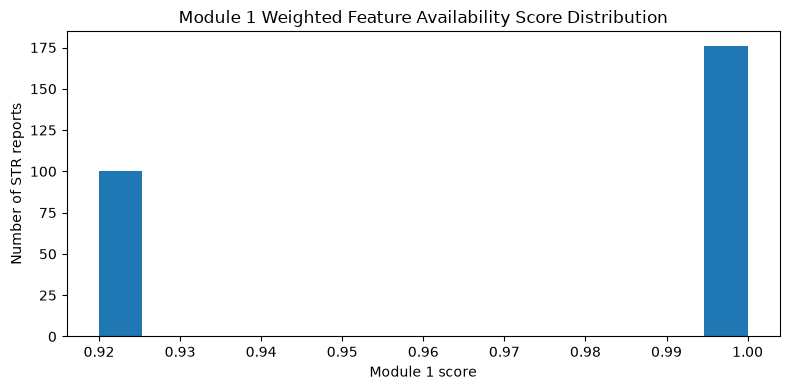

In [11]:

plt.figure(figsize=(8, 4))
plt.hist(results['module1_weighted_score'], bins=15)
plt.title('Module 1 Weighted Feature Availability Score Distribution')
plt.xlabel('Module 1 score')
plt.ylabel('Number of STR reports')
plt.tight_layout()
plt.show()


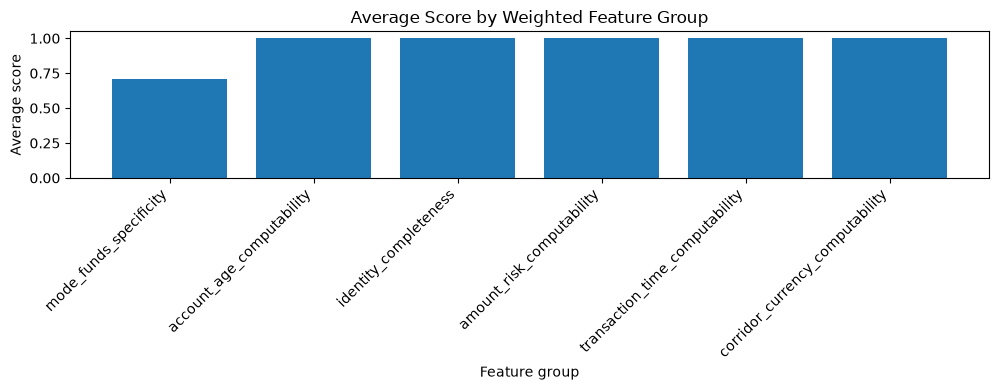

In [12]:

plot_df = group_summary.sort_values('average_score')
plt.figure(figsize=(10, 4))
plt.bar(plot_df['feature_group'], plot_df['average_score'])
plt.title('Average Score by Weighted Feature Group')
plt.xlabel('Feature group')
plt.ylabel('Average score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 11. Bottom reports by Module 1

These are reports where structured fields are weakest for computing important AML features.

In [13]:

bottom_reports = results.sort_values('module1_weighted_score').head(10)[
    ['report_id', 'module1_weighted_score', 'active_transaction_blocks'] + list(GROUP_WEIGHTS.keys()) + ['gaps_text']
]
bottom_reports


,report_id,module1_weighted_score,active_transaction_blocks,account_age_computability,amount_risk_computability,identity_completeness,transaction_time_computability,corridor_currency_computability,mode_funds_specificity,gaps_text
0,RPT-2026-000001,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
18,RPT-2026-000019,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
20,RPT-2026-000021,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
21,RPT-2026-000022,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
23,RPT-2026-000024,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
24,RPT-2026-000025,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
25,RPT-2026-000026,0.92,2,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic | report_transaction_2_transaction: tr...
26,RPT-2026-000027,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
28,RPT-2026-000029,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic
31,RPT-2026-000032,0.92,1,1.0,1.0,1.0,1.0,1.0,0.2,report_transaction: transaction mode or funds-code fields are missing/generic


## 12. Top reports by Module 1

In [14]:

top_reports = results.sort_values('module1_weighted_score', ascending=False).head(10)[
    ['report_id', 'module1_weighted_score', 'active_transaction_blocks'] + list(GROUP_WEIGHTS.keys()) + ['gaps_text']
]
top_reports


,report_id,module1_weighted_score,active_transaction_blocks,account_age_computability,amount_risk_computability,identity_completeness,transaction_time_computability,corridor_currency_computability,mode_funds_specificity,gaps_text
275,RPT-2026-000276,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
274,RPT-2026-000275,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
1,RPT-2026-000002,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
258,RPT-2026-000259,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
256,RPT-2026-000257,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
252,RPT-2026-000253,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
251,RPT-2026-000252,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
250,RPT-2026-000251,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
249,RPT-2026-000250,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features
248,RPT-2026-000249,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,structured fields support all selected weighted features


## 13. Most common structured gaps

In [15]:

gap_counter = Counter()
for gaps in results['gaps']:
    for gap in gaps:
        clean_gap = re.sub(r'^report_transaction(_\d+_transaction)?:\s*', '', gap)
        gap_counter[clean_gap] += 1

common_gaps = pd.DataFrame(gap_counter.most_common(15), columns=['gap', 'report_count'])
common_gaps


,gap,report_count
0,structured fields support all selected weighted features,176
1,transaction mode or funds-code fields are missing/generic,127


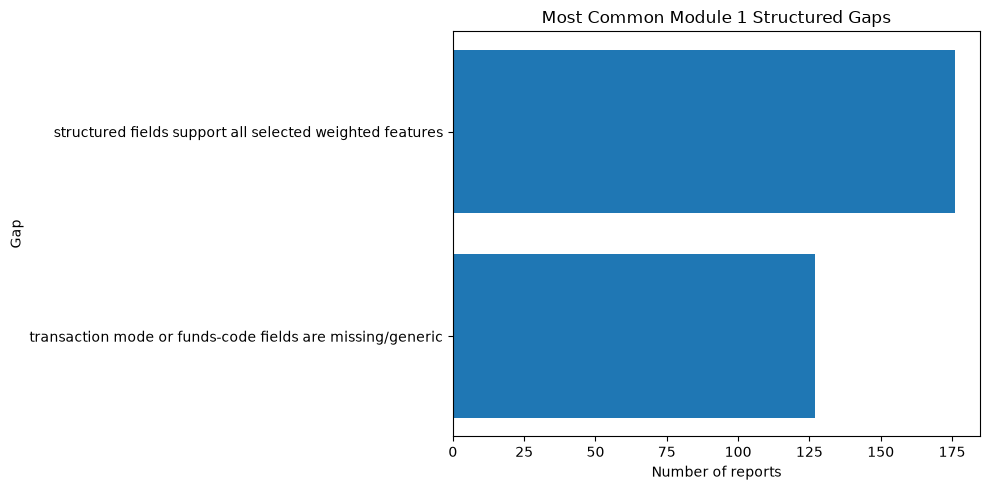

In [16]:

if not common_gaps.empty:
    plot_gaps = common_gaps.sort_values('report_count').tail(10)
    plt.figure(figsize=(10, 5))
    plt.barh(plot_gaps['gap'], plot_gaps['report_count'])
    plt.title('Most Common Module 1 Structured Gaps')
    plt.xlabel('Number of reports')
    plt.ylabel('Gap')
    plt.tight_layout()
    plt.show()


## 14. Export scored output

The output CSV can be used later by the final composite scorer.

In [18]:

OUTPUT_PATH = Path('module1_weighted_feature_availability_scores.csv')
results.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')


Saved: module1_weighted_feature_availability_scores.csv


In [21]:
print(df.loc[0,"report_transaction_transmode_code"])
print(df.loc[1,"report_transaction_transmode_code"])

Z
A


## 15. Final interpretation for presentation

Use this explanation in your notebook, report, or presentation:

> Module 1 was redesigned from simple column completeness into a weighted feature availability score. We mapped important AML features back to the raw STR fields required to compute them. Higher weight was given to account age computability, amount-risk features, sender/receiver identity, transaction date/time, cross-border/currency features, and transaction mode/funds-code specificity. Fields that were useful but not available, such as PEP flags, sanctions flags, adverse media, country risk scores, and full transaction history, were documented in a should-be-included list.

This framing is stronger because it shows not only whether fields are filled, but whether the STR contains the structured information needed for meaningful AML analysis.